# Análisis exploratorio de datos (EDA) para el caso de estudio de UPN   

## 1. Carga y limpieza de datos     

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

# --------------- Configuración global ---------------
pd.options.display.max_columns = None
sns.set_theme(style="whitegrid", palette="muted")
FIGSIZE = (10, 5)
COLOR_MAIN = "#378ADD"
COLOR_TARGET = "#E24B4A"
COLOR_MUTED = "#888780"

In [3]:
# --------------- Carga del dataset---------------
path = "data/PROSPECTOS_UPN_GENERAL.csv"
df = pd.read_csv(path, encoding="cp1252", low_memory=False)

In [ ]:
# Reemplazar ceros-como-missing en variables numéricas
df["EDAD"] = df["EDAD"].replace(0, np.nan)
df["AÑO_EGRESO"] = df["AÑO_EGRESO"].replace(0.0, np.nan)

for col in ["FECHA_REGISTRO", "FECHA_PM", "FECHA_ULT_VALORACION"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

C:\Users\josel\AppData\Local\Temp\ipykernel_27604\217274902.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors="coerce")


## 1.1 Descripción del dataset

In [3]:

n_total = len(df)
n_matriculados = df["PM"].sum()  # PM = 1 → matriculado
n_campanas = df["CAMPAÑA"].nunique()
n_variables = df.shape[1]

resumen = pd.DataFrame(
    {
        "Métrica": [
            "Prospectos totales",
            "Matriculados (PM = 1)",
            "Tasa de conversión (%)",
            "Variables",
            "Campañas únicas",
            "Semestres",
        ],
        "Valor": [
            f"{n_total:,}",
            f"{n_matriculados:,}",
            f"{100 * n_matriculados / n_total:.2f}%",
            n_variables,
            n_campanas,
            df["CAMPAÑA"].nunique(),  # ajustar si tienes columna semestre
        ],
    }
)
print("\n=== Descripción del dataset ===")
display(resumen)


=== Descripción del dataset ===


,Métrica,Valor
0,Prospectos totales,"11,679,400"
1,Matriculados (PM = 1),"234,512"
2,Tasa de conversión (%),2.01%
3,Variables,24
4,Campañas únicas,8
5,Semestres,8


## 1.2 Calidad de datos: tipos, missings, desbalance

C:\Users\jhuaytalla\AppData\Local\Temp\ipykernel_31668\3421180694.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = df.select_dtypes(include="object").columns



=== Calidad de datos ===


,NaN (%),SIN DATO (%),Cero=missing (%)
FECHA_PM,98.0,0.0,0.0
AÑO_EGRESO,77.0,0.0,0.0
EDAD,59.2,0.0,0.0
GENERO,38.3,31.3,0.0
FACULTAD,38.1,6.2,0.0
FECHA_ULT_VALORACION,37.2,0.0,0.0
CARRERA,0.0,9.1,0.0
CAMPUS,0.0,0.7,0.0
COLEGIO,0.0,57.1,0.0
DISTRITO,0.0,50.7,0.0


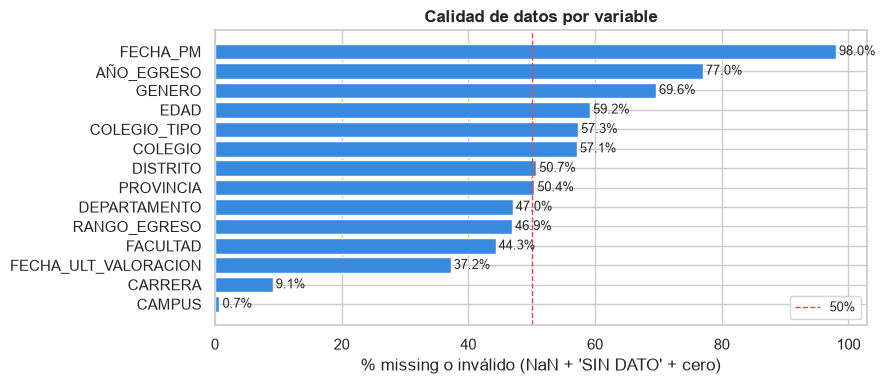

In [4]:
# --- A) Missings reales (NaN) ---
missing_nan = df.isna().sum()
pct_nan = 100 * missing_nan / n_total

# --- B) Missings encubiertos: "SIN DATO" en columnas string ---
str_cols = df.select_dtypes(include="object").columns
missing_str = pd.Series(
    {
        col: (df[col].astype(str).str.strip().str.upper() == "SIN DATO").sum()
        for col in str_cols
    }
)
pct_str = 100 * missing_str / n_total

# --- C) Ceros que son missing: EDAD y AÑO_EGRESO ---
missing_cero = pd.Series(
    {
        "EDAD": (df["EDAD"] == 0).sum(),
        "AÑO_EGRESO": (df["AÑO_EGRESO"] == 0).sum(),
    }
)
pct_cero = 100 * missing_cero / n_total

# --- Tabla consolidada ---
calidad = pd.DataFrame(
    {
        "NaN (%)": pct_nan.round(1),
        "SIN DATO (%)": pct_str.reindex(df.columns).fillna(0).round(1),
        "Cero=missing (%)": pd.Series(
            {"EDAD": pct_cero["EDAD"], "AÑO_EGRESO": pct_cero["AÑO_EGRESO"]}
        )
        .reindex(df.columns)
        .fillna(0)
        .round(1),
    }
).sort_values("NaN (%)", ascending=False)

print("\n=== Calidad de datos ===")
display(calidad[calidad.sum(axis=1) > 0])  # solo filas con algún problema

# --- Gráfico: missings consolidados por variable ---
calidad_plot = (
    calidad["NaN (%)"] + calidad["SIN DATO (%)"] + calidad["Cero=missing (%)"]
).sort_values(ascending=False)
calidad_plot = calidad_plot[calidad_plot > 0]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(calidad_plot.index[::-1], calidad_plot.values[::-1], color=COLOR_MAIN)
ax.axvline(50, color=COLOR_TARGET, linestyle="--", linewidth=1, label="50%")
ax.set_xlabel("% missing o inválido (NaN + 'SIN DATO' + cero)")
ax.set_title("Calidad de datos por variable", fontweight="bold")
ax.legend(fontsize=9)
for bar, val in zip(bars, calidad_plot.values[::-1]):
    ax.text(
        val + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.1f}%",
        va="center",
        fontsize=9,
    )
plt.tight_layout()
plt.savefig("fig_412_calidad.png", dpi=150)
plt.show()

In [6]:
# Verificación rápida antes de graficar
resumen_calidad = (
    pd.DataFrame(
        {
            "NaN (%)": 100 * df.isna().sum() / len(df),
            "SIN DATO (%)": pd.Series(
                {
                    col: 100
                    * (df[col].astype(str).str.strip().str.upper() == "SIN DATO").sum()
                    / len(df)
                    for col in df.select_dtypes("object").columns
                }
            ),
        }
    )
    .fillna(0)
    .round(1)
)

resumen_calidad["Total missing (%)"] = (
    resumen_calidad["NaN (%)"] + resumen_calidad["SIN DATO (%)"]
).round(1)

vars_graf = [
    "RANGO_EDAD",
    "FUENTE_ORIGEN",
    "FACULTAD",
    "GENERO",
    "RANGO_EGRESO",
    "CAMPUS",
]
print(resumen_calidad.loc[vars_graf, "Total missing (%)"])

C:\Users\jhuaytalla\AppData\Local\Temp\ipykernel_31668\2250921251.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes("object").columns


RANGO_EDAD        0.0
FUENTE_ORIGEN     0.0
FACULTAD         44.3
GENERO           69.6
RANGO_EGRESO     46.9
CAMPUS            0.7
Name: Total missing (%), dtype: float64


## 1.3 Distribución de la variable objetivo (PM) y su desbalance

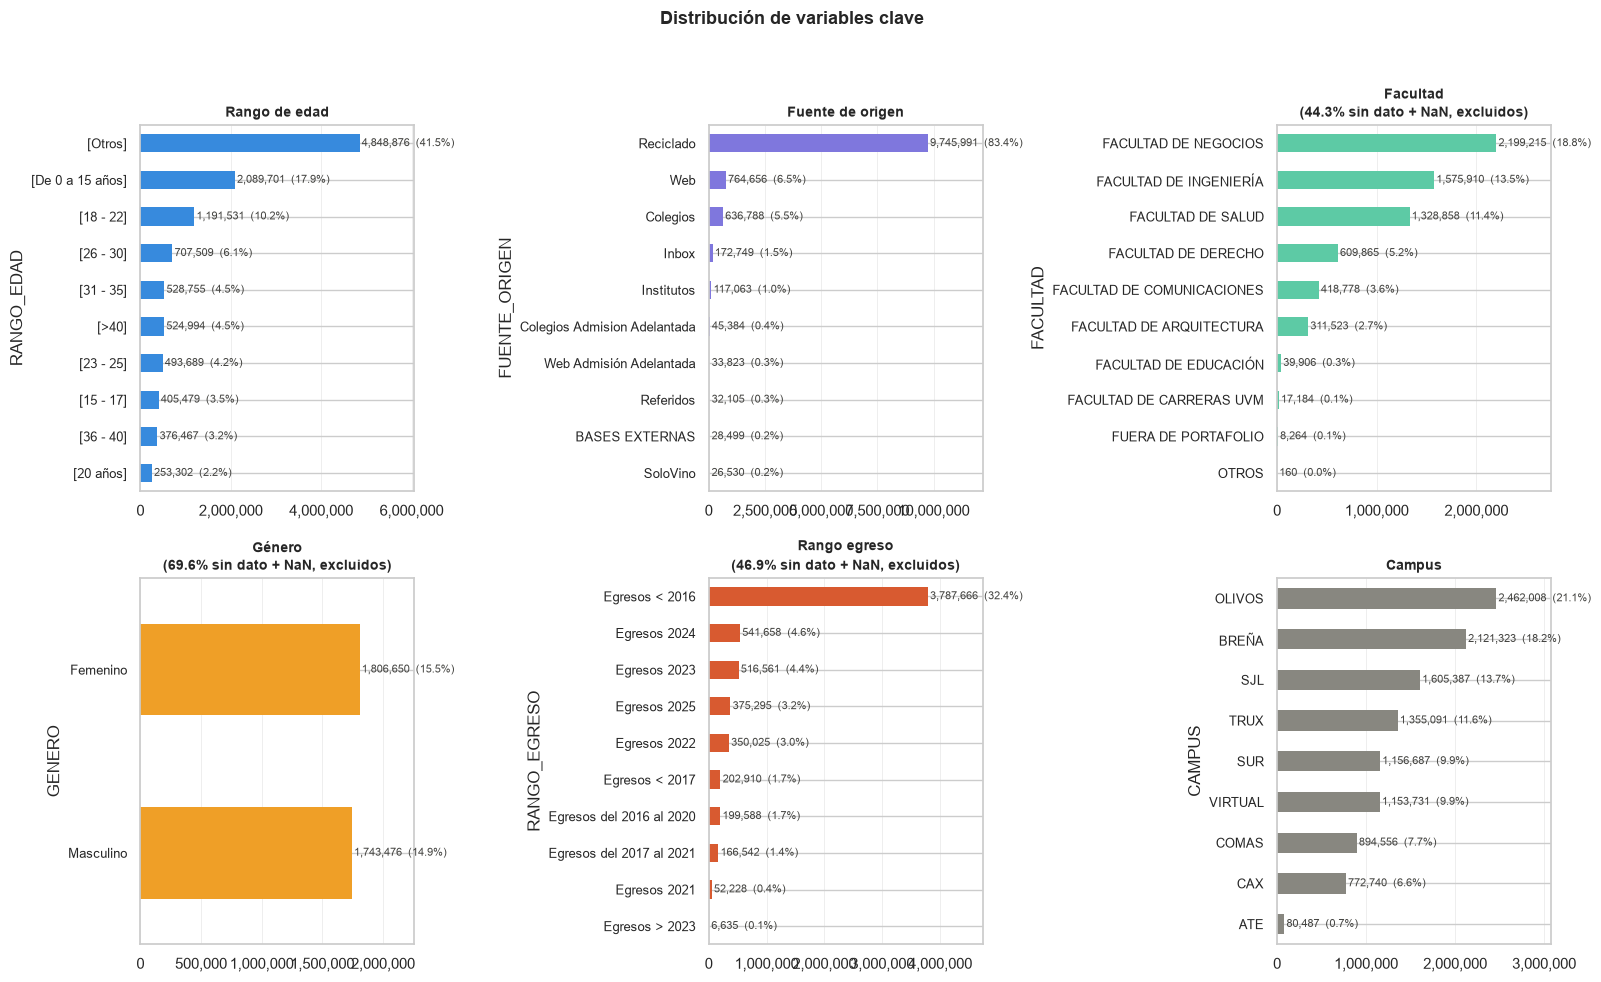

In [7]:
# ============================================================
# DISTRIBUCIÓN DE VARIABLES CLAVE
# ============================================================

import matplotlib.ticker as mticker
import matplotlib.pyplot as plt

# Diccionario de missings totales confirmados (de tu tabla 4.1.2)
MISSING_TOTAL = {
    "RANGO_EDAD": 0.0,
    "FUENTE_ORIGEN": 0.0,
    "FACULTAD": 44.3,
    "GENERO": 69.6,
    "RANGO_EGRESO": 46.9,
    "CAMPUS": 0.7,
}


def plot_top(ax, serie, titulo, n=10, color=COLOR_MAIN, excluir_sin_dato=True):
    s = serie.copy()
    mask_sin_dato = s.astype(str).str.strip().str.upper() == "SIN DATO"
    if excluir_sin_dato:
        s = s[~mask_sin_dato].dropna()

    top = s.value_counts().head(n)
    if top.empty:
        ax.set_visible(False)
        return

    top[::-1].plot(kind="barh", ax=ax, color=color, edgecolor="none")

    # Título con missing total si supera 5%
    pct_inv = MISSING_TOTAL.get(serie.name, 0)
    nota = f"\n({pct_inv:.1f}% sin dato + NaN, excluidos)" if pct_inv > 5 else ""
    ax.set_title(f"{titulo}{nota}", fontsize=10, fontweight="bold", linespacing=1.5)

    xmax = top.max()
    ax.set_xlim(0, xmax * 1.25)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

    for p in ax.patches:
        val = int(p.get_width())
        pct = 100 * val / len(serie)
        ax.text(
            p.get_width() + xmax * 0.01,
            p.get_y() + p.get_height() / 2,
            f"{val:,}  ({pct:.1f}%)",
            va="center",
            fontsize=8,
            color="#444441",
        )

    ax.tick_params(axis="y", labelsize=9)
    ax.grid(axis="x", linewidth=0.4, alpha=0.6)
    ax.set_axisbelow(True)


# ── Subplots ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Distribución de variables clave", fontweight="bold", fontsize=13)

plot_top(axes[0, 0], df["RANGO_EDAD"], "Rango de edad", color=COLOR_MAIN)
plot_top(axes[0, 1], df["FUENTE_ORIGEN"], "Fuente de origen", color="#7F77DD")
plot_top(axes[0, 2], df["FACULTAD"], "Facultad", color="#5DCAA5")
plot_top(axes[1, 0], df["GENERO"], "Género", n=5, color="#EF9F27")
plot_top(axes[1, 1], df["RANGO_EGRESO"], "Rango egreso", color="#D85A30")
plot_top(axes[1, 2], df["CAMPUS"], "Campus", color=COLOR_MUTED)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("fig_413_distribuciones.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
# Hallazgos clave 4.1.3 — para texto del informe
print("""
HALLAZGOS 4.1.3:
1. RANGO_EDAD: '[Otros]' = 41.5% → tratar como missing en feature engineering
2. FUENTE_ORIGEN: 'Reciclado' = 83.4% → base muy sesgada a un canal
   Implicancia: evaluar modelos segmentados por fuente en etapas posteriores
3. RANGO_EGRESO: 'Egresos < 2016' domina → crear flag 'es_egresado_reciente'
4. GENERO: solo 30.4% tiene dato válido → feature de baja cobertura
5. FACULTAD: 44.3% sin dato → reconstruir desde CARRERA antes del modelado
""")


HALLAZGOS 4.1.3:
1. RANGO_EDAD: '[Otros]' = 41.5% → tratar como missing en feature engineering
2. FUENTE_ORIGEN: 'Reciclado' = 83.4% → base muy sesgada a un canal
   Implicancia: evaluar modelos segmentados por fuente en etapas posteriores
3. RANGO_EGRESO: 'Egresos < 2016' domina → crear flag 'es_egresado_reciente'
4. GENERO: solo 30.4% tiene dato válido → feature de baja cobertura
5. FACULTAD: 44.3% sin dato → reconstruir desde CARRERA antes del modelado



## 1.4 Desbalance del target (PM)

In [9]:
# ============================================================
# DESBALANCE DEL TARGET
# ============================================================

conteo_target = df["PM"].value_counts()
ratio = conteo_target[0] / conteo_target[1]
conteo_target = conteo_target.rename({0: "No matriculado", 1: "Matriculado"})

print("\n=== Desbalance del target (PM) ===")
print(
    conteo_target.to_frame("Registros").assign(
        Porcentaje=lambda x: (100 * x["Registros"] / n_total).round(2)
    )
)
print(f"\nRatio desbalance: 1 : {ratio:.0f}")




=== Desbalance del target (PM) ===
                Registros  Porcentaje
PM                                   
No matriculado   11444888       97.99
Matriculado        234512        2.01

Ratio desbalance: 1 : 49


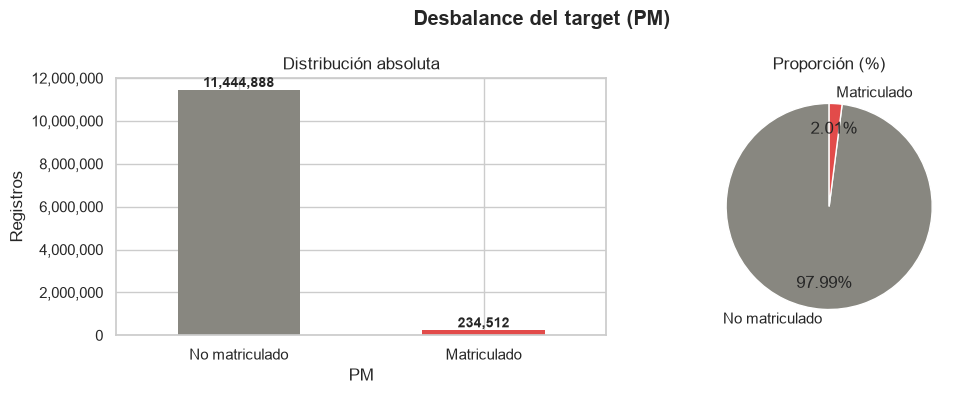

,Clase,Registros,Porcentaje
0,No matriculado (0),11444888,97.99%
1,Matriculado (1),234512,2.01%



Ratio: 1 : 49  →  problema de SEVERO desbalance de clases


In [10]:
# --- Gráfico de desbalance ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle("Desbalance del target (PM)", fontweight="bold")

# Barras absolutas
colores = [COLOR_MUTED, COLOR_TARGET]
conteo_target.plot(kind="bar", ax=axes[0], color=colores, width=0.5, edgecolor="none")
axes[0].set_title("Distribución absoluta")
axes[0].set_ylabel("Registros")
axes[0].set_xticklabels(conteo_target.index, rotation=0)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for p in axes[0].patches:
    axes[0].annotate(
        f"{int(p.get_height()):,}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

# Pastel con zoom en la clase minoritaria
pcts = 100 * conteo_target / n_total
wedges, texts, autotexts = axes[1].pie(
    pcts,
    labels=conteo_target.index,
    colors=colores,
    autopct="%1.2f%%",
    startangle=90,
    pctdistance=0.75,
    wedgeprops={"linewidth": 1, "edgecolor": "white"},
)
axes[1].set_title("Proporción (%)")

plt.tight_layout()
plt.savefig("fig_414_desbalance.png", dpi=150)
plt.show()

# --- Tabla resumen de desbalance para el informe ---
tabla_desbalance = pd.DataFrame(
    {
        "Clase": ["No matriculado (0)", "Matriculado (1)"],
        "Registros": [
            conteo_target.loc["No matriculado"],
            conteo_target.loc["Matriculado"],
        ],
        "Porcentaje": [
            f"{100 * conteo_target.loc['No matriculado'] / n_total:.2f}%",
            f"{100 * conteo_target.loc['Matriculado'] / n_total:.2f}%",
        ],
    }
)
display(tabla_desbalance)
print(f"\nRatio: 1 : {ratio:.0f}  →  problema de SEVERO desbalance de clases")

In [11]:
print("Distribución REG:", df["REG"].value_counts().to_dict())
print("Distribución PM:", df["PM"].value_counts().to_dict())
print("Cruces REG=1 & PM=0:", ((df["REG"] == 1) & (df["PM"] == 0)).sum())

Distribución REG: {1: 11679400}
Distribución PM: {0: 11444888, 1: 234512}
Cruces REG=1 & PM=0: 11444888


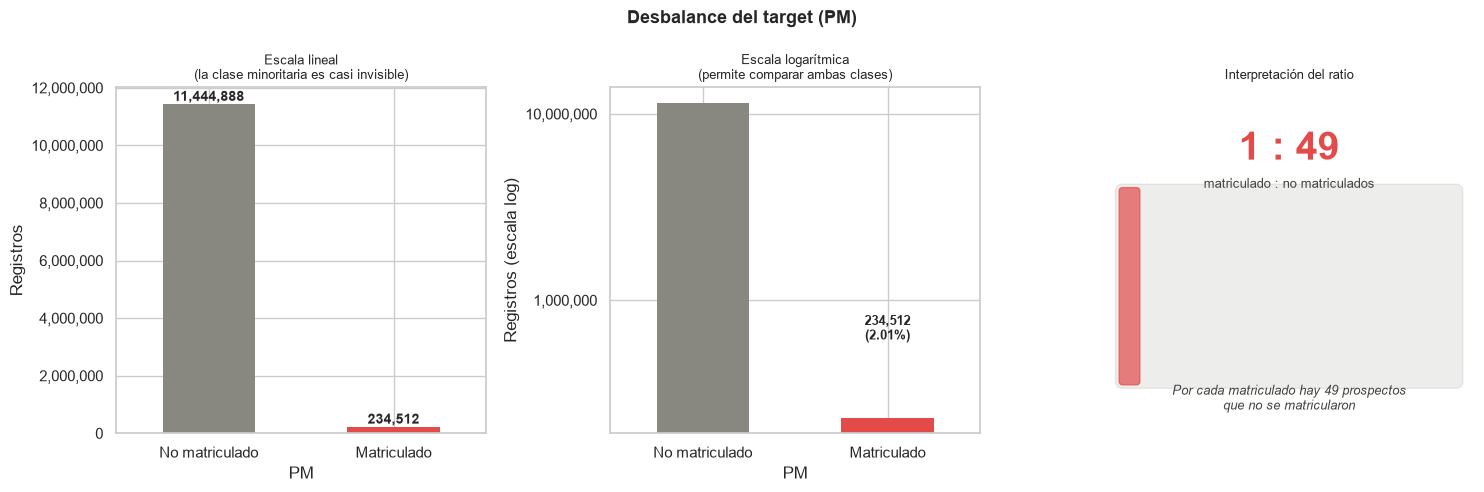

,Clase,Registros,Porcentaje
0,No matriculado (0),11444888,97.99%
1,Matriculado (1),234512,2.01%



Ratio: 1 : 49  →  problema de SEVERO desbalance de clases

Implicancias para el modelado:
  - Accuracy no es métrica válida (un modelo que predice siempre 0 logra 97.99%)
  - Métricas objetivo: F1-score, Precision-Recall AUC, ROC-AUC
  - Técnicas a evaluar: SMOTE, class_weight='balanced', umbral de decisión ajustado


In [12]:
# ── Gráfico ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Desbalance del target (PM)", fontweight="bold", fontsize=13)

colores = [COLOR_MUTED, COLOR_TARGET]

# ── Panel 1: barras absolutas (escala lineal) ─────────────────────────────────
conteo_target.plot(kind="bar", ax=axes[0], color=colores, width=0.5, edgecolor="none")
axes[0].set_title("Escala lineal\n(la clase minoritaria es casi invisible)", fontsize=9)
axes[0].set_ylabel("Registros")
axes[0].set_xticklabels(conteo_target.index, rotation=0)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for p in axes[0].patches:
    axes[0].annotate(
        f"{int(p.get_height()):,}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

# ── Panel 2: barras en escala logarítmica (hace visible el desbalance real) ───
conteo_target.plot(kind="bar", ax=axes[1], color=colores, width=0.5, edgecolor="none")
axes[1].set_yscale("log")
axes[1].set_title("Escala logarítmica\n(permite comparar ambas clases)", fontsize=9)
axes[1].set_ylabel("Registros (escala log)")
axes[1].set_xticklabels(conteo_target.index, rotation=0)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for p in axes[1].patches:
    val = int(p.get_height())
    pct = 100 * val / n_total
    axes[1].annotate(
        f"{val:,}\n({pct:.2f}%)",
        (p.get_x() + p.get_width() / 2, p.get_height() * 2.5),
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
    )

# ── Panel 3: visualización del ratio como unidades ───────────────────────────
# Muestra "por cada 1 matriculado hay N no matriculados" de forma gráfica
ratio_int = int(round(ratio))
ax3 = axes[2]
ax3.set_xlim(0, 1)
ax3.set_ylim(0, 1)
ax3.axis("off")
ax3.set_title("Interpretación del ratio", fontsize=9)

# Rectángulo de fondo (clase mayoritaria)
from matplotlib.patches import FancyBboxPatch

bg = FancyBboxPatch(
    (0.05, 0.15),
    0.9,
    0.55,
    boxstyle="round,pad=0.02",
    facecolor=COLOR_MUTED,
    alpha=0.15,
    edgecolor=COLOR_MUTED,
    linewidth=1,
)
ax3.add_patch(bg)

# Rectángulo pequeño (clase minoritaria, proporcional)
prop = max(1 / (ratio_int + 1), 0.04)
mini = FancyBboxPatch(
    (0.05, 0.15),
    0.9 * prop,
    0.55,
    boxstyle="round,pad=0.01",
    facecolor=COLOR_TARGET,
    alpha=0.7,
    edgecolor=COLOR_TARGET,
    linewidth=1,
)
ax3.add_patch(mini)

ax3.text(
    0.5,
    0.82,
    f"1 : {ratio_int}",
    ha="center",
    va="center",
    fontsize=28,
    fontweight="bold",
    color=COLOR_TARGET,
)
ax3.text(
    0.5,
    0.72,
    "matriculado : no matriculados",
    ha="center",
    va="center",
    fontsize=9,
    color="#444441",
)
ax3.text(
    0.5,
    0.10,
    f"Por cada matriculado hay {ratio_int} prospectos\nque no se matricularon",
    ha="center",
    va="center",
    fontsize=9,
    color="#444441",
    style="italic",
)

plt.tight_layout()
plt.savefig("fig_414_desbalance.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Tabla resumen ─────────────────────────────────────────────────────────────
tabla_desbalance = pd.DataFrame(
    {
        "Clase": ["No matriculado (0)", "Matriculado (1)"],
        "Registros": [
            conteo_target.loc["No matriculado"],
            conteo_target.loc["Matriculado"],
        ],
        "Porcentaje": [
            f"{100 * conteo_target.loc['No matriculado'] / n_total:.2f}%",
            f"{100 * conteo_target.loc['Matriculado']    / n_total:.2f}%",
        ],
    }
)
display(tabla_desbalance)
print(f"\nRatio: 1 : {ratio:.0f}  →  problema de SEVERO desbalance de clases")
print("\nImplicancias para el modelado:")
print(
    "  - Accuracy no es métrica válida (un modelo que predice siempre 0 logra 97.99%)"
)
print("  - Métricas objetivo: F1-score, Precision-Recall AUC, ROC-AUC")
print(
    "  - Técnicas a evaluar: SMOTE, class_weight='balanced', umbral de decisión ajustado"
)

## 1.5 Tasa de conversión por variable (Análisis bivariado)

Tasa de conversión global: 2.0079%

=== Tasas de conversión por variable ===

--- Fuente de origen ---
                                total  matriculados       tasa
FUENTE_ORIGEN                                                 
SoloVino                        26530         10115  38.126649
Referidos                       32105         10854  33.807818
Inbound                         20829          4658  22.363052
Inbox                          172749         16856   9.757509
Colegios Admision Adelantada    45384          3087   6.801957
Web                            764656         44954   5.878983
Colegios                       636788         24547   3.854815
Web Admisión Adelantada         33823          1087   3.213789
Reciclado                     9745991        116247   1.192767
Eventos Mkt                     14405           164   1.138494
Institutos                     117063          1139   0.972980
BECAS                           11329           108   0.953306
Empresas       

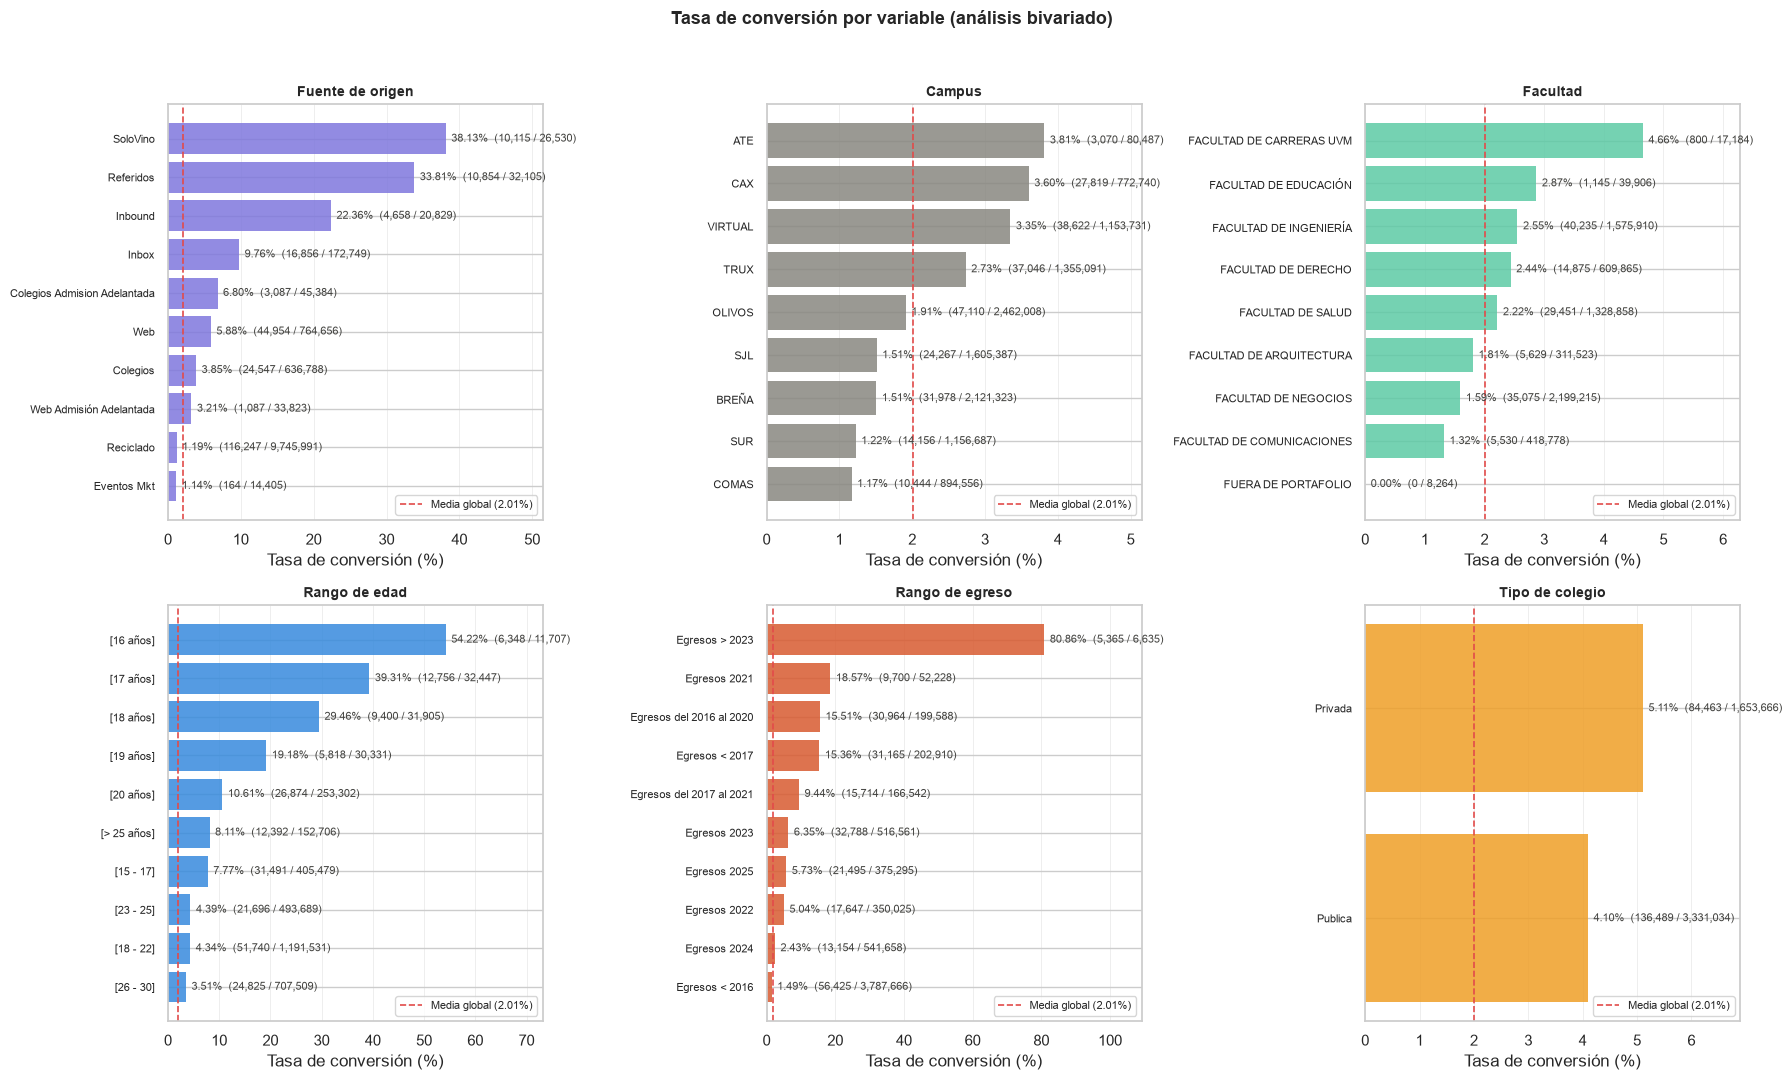

In [13]:
# ============================================================
# TASA DE CONVERSIÓN POR VARIABLE (ANÁLISIS BIVARIADO)
# ============================================================


def tasa_conversion(df, variable, top_n=10, min_registros=500):
    """
    Para cada categoría de `variable` calcula:
      - total de prospectos
      - matriculados (PM = 1)
      - tasa de conversión (%)
    Filtra categorías con menos de min_registros para evitar ruido.
    Excluye 'SIN DATO' y NaN.
    """
    s = df[variable].astype(str).str.strip()
    mask_valido = (s.str.upper() != "SIN DATO") & (s != "nan")
    temp = df[mask_valido].copy()
    temp[variable] = temp[variable].astype(str).str.strip()

    resumen = (
        temp.groupby(variable)["PM"]
        .agg(total="count", matriculados="sum")
        .assign(tasa=lambda x: 100 * x["matriculados"] / x["total"])
        .query("total >= @min_registros")
        .sort_values("tasa", ascending=False)
        .head(top_n)
    )
    return resumen


def plot_conversion(
    ax,
    df,
    variable,
    titulo,
    top_n=10,
    min_registros=500,
    color_bar="#378ADD",
    tasa_global=None,
):
    """
    Gráfico horizontal con:
      - barra = tasa de conversión (%)
      - anotación = tasa% + (N matriculados / total)
      - línea vertical = tasa global de referencia
    """
    resumen = tasa_conversion(df, variable, top_n, min_registros)
    if resumen.empty:
        ax.set_visible(False)
        return

    resumen_plot = resumen.sort_values("tasa", ascending=True)

    bars = ax.barh(
        resumen_plot.index,
        resumen_plot["tasa"],
        color=color_bar,
        alpha=0.85,
        edgecolor="none",
    )

    # Línea de tasa global
    if tasa_global:
        ax.axvline(
            tasa_global,
            color="#E24B4A",
            linestyle="--",
            linewidth=1.2,
            label=f"Media global ({tasa_global:.2f}%)",
        )
        ax.legend(fontsize=8, loc="lower right")

    # Etiquetas
    xmax = resumen_plot["tasa"].max()
    ax.set_xlim(0, xmax * 1.35)
    for bar, (_, row) in zip(bars, resumen_plot.iterrows()):
        ax.text(
            bar.get_width() + xmax * 0.02,
            bar.get_y() + bar.get_height() / 2,
            f"{row['tasa']:.2f}%  ({int(row['matriculados']):,} / {int(row['total']):,})",
            va="center",
            fontsize=8,
            color="#444441",
        )

    ax.set_title(titulo, fontsize=10, fontweight="bold")
    ax.set_xlabel("Tasa de conversión (%)")
    ax.tick_params(axis="y", labelsize=8)
    ax.grid(axis="x", linewidth=0.4, alpha=0.6)
    ax.set_axisbelow(True)


# ── Tasa global de referencia ─────────────────────────────────────────────────
tasa_global = 100 * df["PM"].sum() / len(df)
print(f"Tasa de conversión global: {tasa_global:.4f}%")

# ── Tablas resumen (para el informe) ─────────────────────────────────────────
variables_analizar = {
    "FUENTE_ORIGEN": "Fuente de origen",
    "CAMPUS": "Campus",
    "FACULTAD": "Facultad",
    "RANGO_EDAD": "Rango de edad",
    "RANGO_EGRESO": "Rango de egreso",
    "COLEGIO_TIPO": "Tipo de colegio",
}

print("\n=== Tasas de conversión por variable ===\n")
for var, nombre in variables_analizar.items():
    print(f"--- {nombre} ---")
    t = tasa_conversion(df, var, top_n=15, min_registros=500)
    print(t.to_string())
    print()

# ── Gráficos ──────────────────────────────────────────────────────────────────
colores = {
    "FUENTE_ORIGEN": "#7F77DD",
    "CAMPUS": "#888780",
    "FACULTAD": "#5DCAA5",
    "RANGO_EDAD": "#378ADD",
    "RANGO_EGRESO": "#D85A30",
    "COLEGIO_TIPO": "#EF9F27",
}

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle(
    "Tasa de conversión por variable (análisis bivariado)",
    fontweight="bold",
    fontsize=13,
)

pares = list(zip(variables_analizar.items(), axes.flatten()))
for (var, nombre), ax in pares:
    plot_conversion(
        ax,
        df,
        var,
        titulo=nombre,
        top_n=10,
        min_registros=500,
        color_bar=colores[var],
        tasa_global=tasa_global,
    )

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("fig_415_conversion_bivariado.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
# Diagnóstico de anomalía: Egresos > 2023
mask = df["RANGO_EGRESO"] == "Egresos > 2023"
anomalia = df[mask]

print(f"Total registros 'Egresos > 2023': {len(anomalia):,}")
print(f"Matriculados: {anomalia['PM'].sum():,}")
print(f"Tasa: {100 * anomalia['PM'].mean():.2f}%")
print()

# ¿De qué campaña vienen?
print("Distribución por BASE_ST:")
print(anomalia["BASE_ST"].value_counts().head(10))
print()

# ¿De qué fuente?
print("Distribución por FUENTE_ORIGEN:")
print(anomalia["FUENTE_ORIGEN"].value_counts().head(10))
print()

# ¿Cuándo se registraron?
print("Año de registro:")
print(anomalia["FECHA_REGISTRO"].dt.year.value_counts().sort_index())

Total registros 'Egresos > 2023': 6,635
Matriculados: 5,365
Tasa: 80.86%

Distribución por BASE_ST:
BASE_ST
RECICLADOS                     2322
WEB                            1101
RECICLADOS PARA MKT DIRECTO     951
INBOX                           704
SOLOVINO                        600
REFERIDOS                       407
INBOUND                         327
COLEGIOS                        154
NEW REINGRESO                    37
INSTITUTOS                       30
Name: count, dtype: int64

Distribución por FUENTE_ORIGEN:
FUENTE_ORIGEN
Reciclado                       3309
Web                             1089
Inbox                            704
SoloVino                         600
Referidos                        408
Inbound                          327
Colegios                         139
Institutos                        30
Colegios Admision Adelantada      15
Web Admisión Adelantada           11
Name: count, dtype: int64

Año de registro:
FECHA_REGISTRO
2013       1
2014       6
2015

In [15]:
# Diagnóstico profundo de Egresos > 2023
mask = df["RANGO_EGRESO"] == "Egresos > 2023"
anomalia = df[mask]

# 1. Confirmar nulos en FECHA_REGISTRO
print(
    f"FECHA_REGISTRO nula: {anomalia['FECHA_REGISTRO'].isna().sum():,} de {len(anomalia):,}"
)

# 2. Revisar AÑO_EGRESO real (valor numérico)
print("\nAÑO_EGRESO valores únicos:")
print(anomalia["AÑO_EGRESO"].value_counts().sort_index().head(20))

# 3. Cruce con PM: ¿los matriculados tienen fecha de PM?
print("\nFECHA_PM no nula en matriculados:")
mat = anomalia[anomalia["PM"] == 1]
print(f"  Con FECHA_PM: {mat['FECHA_PM'].notna().sum():,}")
print(f"  Sin FECHA_PM: {mat['FECHA_PM'].isna().sum():,}")

# 4. ¿Qué campaña tienen?
print("\nCAMPAÑA:")
print(anomalia["CAMPAÑA"].value_counts().head(10))

# 5. Comparar perfil con el resto del dataset
print("\n--- Comparación de tasas por fuente: Egresos > 2023 vs. resto ---")
comp = (
    df.groupby(
        [
            "FUENTE_ORIGEN",
            df["RANGO_EGRESO"]
            .eq("Egresos > 2023")
            .map({True: "Egresos > 2023", False: "Resto"}),
        ]
    )["PM"]
    .mean()
    .mul(100)
    .round(2)
    .unstack()
)
print(comp)

FECHA_REGISTRO nula: 0 de 6,635

AÑO_EGRESO valores únicos:
AÑO_EGRESO
2021.0    2618
2022.0    3109
2023.0     114
2024.0     494
2025.0     169
2026.0       8
2027.0       7
2028.0       5
2029.0       8
2030.0       5
2031.0       4
2032.0       2
2033.0       8
2034.0       4
2035.0       3
2036.0       4
2037.0       2
2038.0       1
2039.0       2
2040.0       3
Name: count, dtype: int64

FECHA_PM no nula en matriculados:
  Con FECHA_PM: 5,365
  Sin FECHA_PM: 0

CAMPAÑA:
CAMPAÑA
2023-02    3115
2022-02    2705
2024-01     761
2023-01      54
Name: count, dtype: int64

--- Comparación de tasas por fuente: Egresos > 2023 vs. resto ---
RANGO_EGRESO                  Egresos > 2023   Resto
FUENTE_ORIGEN                                       
Academias                                NaN   22.22
AdmisionOL                            100.00   27.76
BASES EXTERNAS                           NaN    0.46
BECAS                                    NaN    0.95
Bachiller                          

In [16]:
# ============================================================
# DECISIÓN DOCUMENTADA: Exclusión de registros retroactivos
# ============================================================

# Criterio: registros con RANGO_EGRESO = "Egresos > 2023"
# tienen FECHA_REGISTRO nula en el 100% de los casos,
# FECHA_PM presente en todos los matriculados,
# y pertenecen a campañas 2022-02 / 2023-02.
# Conclusión: fueron ingresados post-matrícula, no son prospectos reales.

n_antes = len(df)
mask_retroactivos = df["RANGO_EGRESO"] == "Egresos > 2023"

print("=== Registros retroactivos detectados ===")
print(f"  Total a excluir:     {mask_retroactivos.sum():,}")
print(f"  Matriculados en ese grupo: {df[mask_retroactivos]['PM'].sum():,}")
print(f"  Tasa de conversión:  {100 * df[mask_retroactivos]['PM'].mean():.2f}%")
print(
    f"  FECHA_REGISTRO nula: {df[mask_retroactivos]['FECHA_REGISTRO'].isna().sum():,}"
)

# Excluir
df = df[~mask_retroactivos].copy()

n_despues = len(df)
print(f"\nDataset antes:  {n_antes:,}")
print(f"Dataset después: {n_despues:,}")
print(f"Registros excluidos: {n_antes - n_despues:,}")

# Verificar nuevo target
print(f"\nNuevo total matriculados: {df['PM'].sum():,}")
print(f"Nueva tasa global:        {100 * df['PM'].mean():.4f}%")

=== Registros retroactivos detectados ===
  Total a excluir:     6,635
  Matriculados en ese grupo: 5,365
  Tasa de conversión:  80.86%
  FECHA_REGISTRO nula: 0

Dataset antes:  11,679,400
Dataset después: 11,672,765
Registros excluidos: 6,635

Nuevo total matriculados: 229,147
Nueva tasa global:        1.9631%


## 1.6 Análisis temporal

In [17]:
# ============================================================
# ANÁLISIS TEMPORAL
# ============================================================

# Extraer componentes temporales
df["anio_registro"] = df["FECHA_REGISTRO"].dt.year
df["mes_registro"] = df["FECHA_REGISTRO"].dt.month
df["periodo"] = df["FECHA_REGISTRO"].dt.to_period("M")  # año-mes

# ── Verificar cobertura temporal ──────────────────────────────────────────────
print("=== Cobertura temporal ===")
print(f"Fecha mínima: {df['FECHA_REGISTRO'].min()}")
print(f"Fecha máxima: {df['FECHA_REGISTRO'].max()}")
print(f"Registros sin fecha: {df['FECHA_REGISTRO'].isna().sum():,}")
print(f"Periodos únicos (año-mes): {df['periodo'].nunique()}")
print(f"\nRegistros por año:")
print(df["anio_registro"].value_counts().sort_index().to_string())

=== Cobertura temporal ===
Fecha mínima: 2013-08-12 00:00:00
Fecha máxima: 2026-04-11 12:00:00
Registros sin fecha: 0
Periodos únicos (año-mes): 153

Registros por año:
anio_registro
2013      31054
2014     120894
2015     136732
2016     206698
2017     256737
2018     316978
2019     385041
2020     408728
2021     818444
2022     889826
2023     776196
2024    3275911
2025    3904020
2026     145506


Registros con fecha válida: 11,672,765 (100.0% del total)
Registros sin fecha:        0 (excluidos del análisis temporal)

=== Serie mensual ===
            registros  matriculados       tasa
periodo                                       
2013-08-01       1466            45   3.069577
2013-09-01       8201           105   1.280332
2013-10-01       5265            50   0.949668
2013-11-01       9806            74   0.754640
2013-12-01       6316            76   1.203293
2014-01-01      15481            74   0.478005
2014-02-01       4630            57   1.231102
2014-03-01      10670            88   0.824742
2014-04-01       5176            39   0.753478
2014-05-01       5913            87   1.471334
2014-06-01      15491           112   0.723000
2014-07-01      15126           146   0.965225
2014-08-01      10064           107   1.063196
2014-09-01       9695            82   0.845797
2014-10-01      12377           122   0.985699
2014-11-01       9602            86   0.895647
2014-12-0

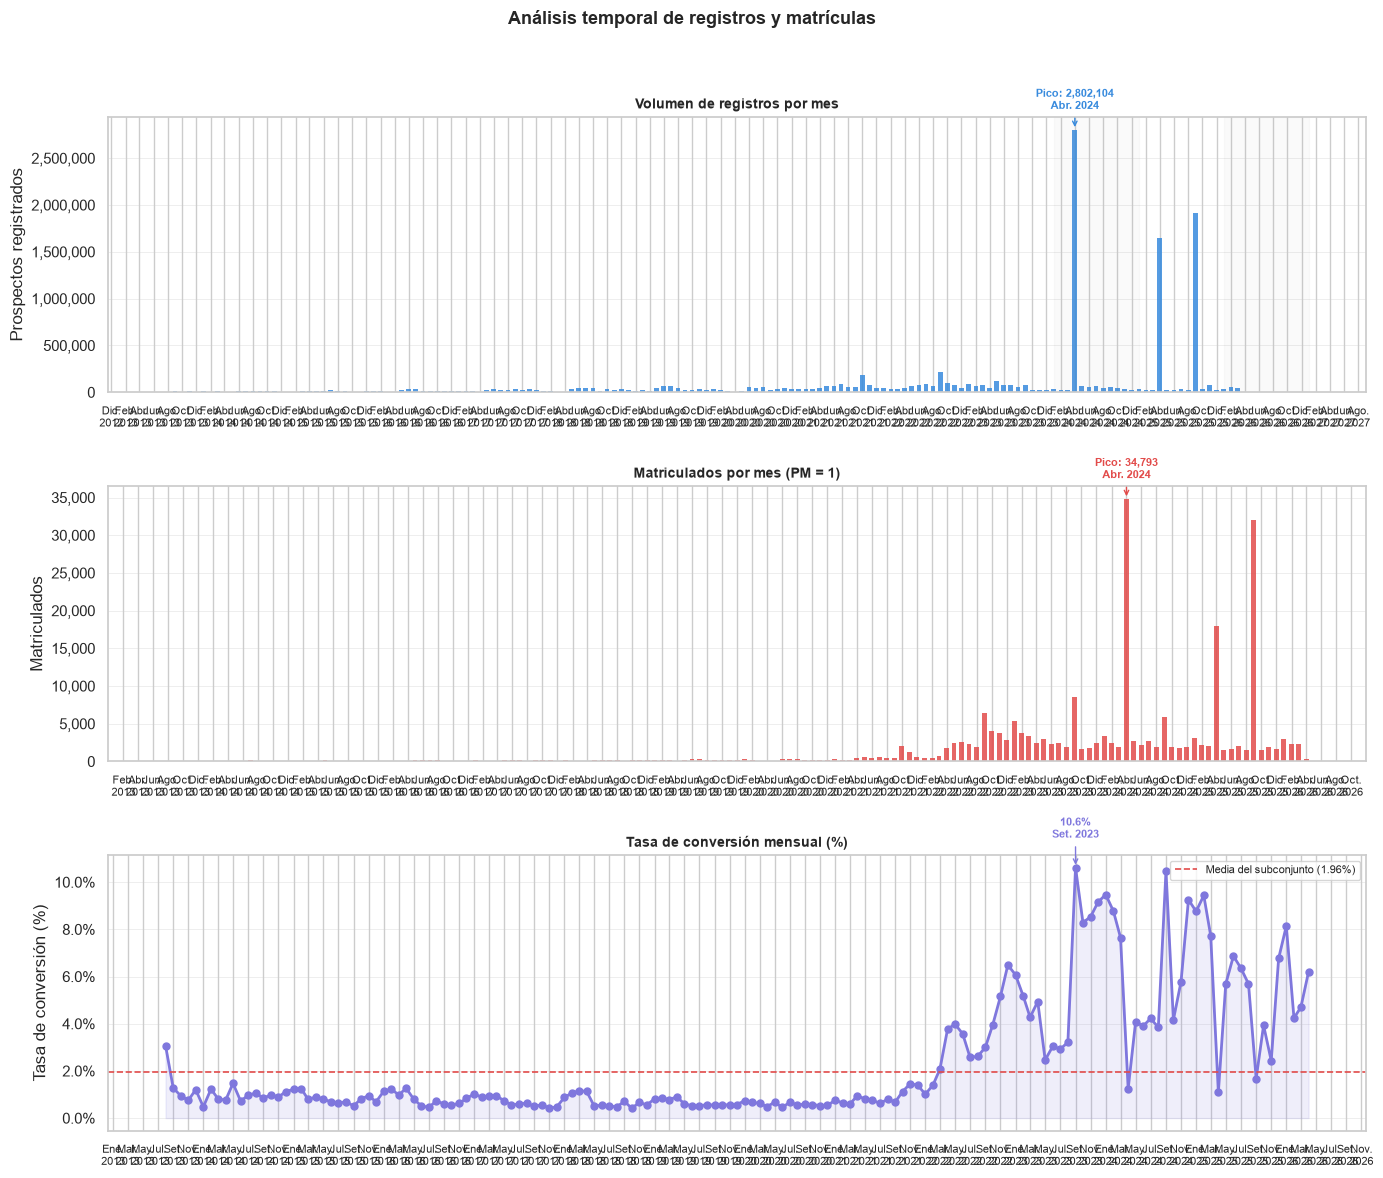


=== Resumen por año (subconjunto con fecha) ===
               registros  matriculados  tasa
anio_registro                               
2013               31054           350  1.13
2014              120894          1075  0.89
2015              136732          1052  0.77
2016              206698          1420  0.69
2017              256737          1567  0.61
2018              316978          1893  0.60
2019              385041          2321  0.60
2020              408728          2394  0.59
2021              818444          7600  0.93
2022              889826         29780  3.35
2023              776196         39076  5.03
2024             3275911         63357  1.93
2025             3904020         69344  1.78
2026              145506          7918  5.44

NOTA METODOLÓGICA:
El análisis temporal cubre 11,672,765 registros (100.0% del dataset).
Los 0 registros sin FECHA_REGISTRO corresponden
mayoritariamente a la campaña RECICLADOS (leads históricos migrados sin fecha de
captación or

In [18]:
# ============================================================
# ANÁLISIS TEMPORAL (subconjunto con fecha válida)
# ============================================================

# Subconjunto con fecha válida
df_fecha = df[df["FECHA_REGISTRO"].notna()].copy()
n_con_fecha = len(df_fecha)
pct_con_fecha = 100 * n_con_fecha / len(df)

print(f"Registros con fecha válida: {n_con_fecha:,} ({pct_con_fecha:.1f}% del total)")
print(
    f"Registros sin fecha:        {df['FECHA_REGISTRO'].isna().sum():,} (excluidos del análisis temporal)"
)

# ── Serie mensual: registros y matriculados ───────────────────────────────────
serie_mensual = (
    df_fecha.groupby("periodo")
    .agg(
        registros=("PM", "count"),
        matriculados=("PM", "sum"),
    )
    .assign(tasa=lambda x: 100 * x["matriculados"] / x["registros"])
    .sort_index()
)

# Convertir periodo a timestamp para matplotlib
serie_mensual.index = serie_mensual.index.to_timestamp()

print("\n=== Serie mensual ===")
print(serie_mensual.to_string())

# ── Figura principal: 3 paneles ───────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle(
    "Análisis temporal de registros y matrículas",
    fontweight="bold",
    fontsize=13,
)

# ── Panel 1: volumen de registros por mes ────────────────────────────────────
ax1 = axes[0]
ax1.bar(
    serie_mensual.index,
    serie_mensual["registros"],
    width=20,
    color=COLOR_MAIN,
    alpha=0.85,
    edgecolor="none",
)
ax1.set_title("Volumen de registros por mes", fontsize=10, fontweight="bold")
ax1.set_ylabel("Prospectos registrados")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax1.grid(axis="y", linewidth=0.4, alpha=0.6)
ax1.set_axisbelow(True)

# Anotar pico máximo
idx_max = serie_mensual["registros"].idxmax()
val_max = serie_mensual["registros"].max()
ax1.annotate(
    f"Pico: {val_max:,}\n{idx_max.strftime('%b %Y')}",
    xy=(idx_max, val_max),
    xytext=(idx_max, val_max * 1.08),
    ha="center",
    fontsize=8,
    color=COLOR_MAIN,
    fontweight="bold",
    arrowprops=dict(arrowstyle="->", color=COLOR_MAIN, lw=1),
)

# Sombrear años
for anio in [2024, 2025, 2026]:
    inicio = pd.Timestamp(f"{anio}-01-01")
    fin = pd.Timestamp(f"{anio}-12-31")
    if anio % 2 == 0:
        ax1.axvspan(inicio, fin, alpha=0.04, color="gray")

# ── Panel 2: matriculados por mes ────────────────────────────────────────────
ax2 = axes[1]
ax2.bar(
    serie_mensual.index,
    serie_mensual["matriculados"],
    width=20,
    color=COLOR_TARGET,
    alpha=0.85,
    edgecolor="none",
)
ax2.set_title("Matriculados por mes (PM = 1)", fontsize=10, fontweight="bold")
ax2.set_ylabel("Matriculados")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax2.grid(axis="y", linewidth=0.4, alpha=0.6)
ax2.set_axisbelow(True)

idx_max2 = serie_mensual["matriculados"].idxmax()
val_max2 = serie_mensual["matriculados"].max()
ax2.annotate(
    f"Pico: {val_max2:,}\n{idx_max2.strftime('%b %Y')}",
    xy=(idx_max2, val_max2),
    xytext=(idx_max2, val_max2 * 1.08),
    ha="center",
    fontsize=8,
    color=COLOR_TARGET,
    fontweight="bold",
    arrowprops=dict(arrowstyle="->", color=COLOR_TARGET, lw=1),
)

# ── Panel 3: tasa de conversión mensual ──────────────────────────────────────
ax3 = axes[2]
ax3.plot(
    serie_mensual.index,
    serie_mensual["tasa"],
    color="#7F77DD",
    linewidth=2,
    marker="o",
    markersize=5,
)
ax3.fill_between(
    serie_mensual.index, serie_mensual["tasa"], alpha=0.12, color="#7F77DD"
)

# Línea de tasa global
tasa_global_limpia = 100 * df_fecha["PM"].mean()
ax3.axhline(
    tasa_global_limpia,
    color=COLOR_TARGET,
    linestyle="--",
    linewidth=1.2,
    label=f"Media del subconjunto ({tasa_global_limpia:.2f}%)",
)
ax3.set_title("Tasa de conversión mensual (%)", fontsize=10, fontweight="bold")
ax3.set_ylabel("Tasa de conversión (%)")
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}%"))
ax3.legend(fontsize=8)
ax3.grid(axis="y", linewidth=0.4, alpha=0.6)
ax3.set_axisbelow(True)

# Anotar pico de tasa
idx_max3 = serie_mensual["tasa"].idxmax()
val_max3 = serie_mensual["tasa"].max()
ax3.annotate(
    f"{val_max3:.1f}%\n{idx_max3.strftime('%b %Y')}",
    xy=(idx_max3, val_max3),
    xytext=(idx_max3, val_max3 * 1.12),
    ha="center",
    fontsize=8,
    color="#7F77DD",
    fontweight="bold",
    arrowprops=dict(arrowstyle="->", color="#7F77DD", lw=1),
)

# Formato eje X compartido
import matplotlib.dates as mdates

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.tick_params(axis="x", labelsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("fig_416_temporal.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Tabla resumen por año ─────────────────────────────────────────────────────
print("\n=== Resumen por año (subconjunto con fecha) ===")
resumen_anual = (
    df_fecha.groupby("anio_registro")["PM"]
    .agg(registros="count", matriculados="sum")
    .assign(tasa=lambda x: (100 * x["matriculados"] / x["registros"]).round(2))
)
resumen_anual.index = resumen_anual.index.astype(int)
print(resumen_anual.to_string())

# ── Nota metodológica para el informe ────────────────────────────────────────
print(f"""
NOTA METODOLÓGICA:
El análisis temporal cubre {n_con_fecha:,} registros ({pct_con_fecha:.1f}% del dataset).
Los {df['FECHA_REGISTRO'].isna().sum():,} registros sin FECHA_REGISTRO corresponden
mayoritariamente a la campaña RECICLADOS (leads históricos migrados sin fecha de
captación original). Los resultados temporales no son generalizables al dataset
completo y deben interpretarse como el comportamiento del subconjunto captado
digitalmente entre abril 2024 y abril 2026.
""")

In [20]:
# Verificación de picos: ¿de qué fuente vienen los meses de carga masiva?
for periodo_check in ["2024-04", "2025-09"]:
    mask = df_fecha["periodo"].astype(str) == periodo_check
    print(f"\n=== {periodo_check} — fuente de origen ===")
    print(df_fecha[mask]["FUENTE_ORIGEN"].value_counts().head(5))
    print(f"Total registros: {mask.sum():,}")
    print(f"Tasa conversión: {100 * df_fecha[mask]['PM'].mean():.2f}%")


=== 2024-04 — fuente de origen ===
FUENTE_ORIGEN
Reciclado                       2660622
Colegios                          88909
Colegios Admision Adelantada      17842
Web                               14992
Inbox                              5156
Name: count, dtype: int64
Total registros: 2,802,104
Tasa conversión: 1.24%

=== 2025-09 — fuente de origen ===
FUENTE_ORIGEN
Reciclado                       1736614
Colegios                         134209
Web                               18846
Colegios Admision Adelantada      12715
BECAS                              4175
Name: count, dtype: int64
Total registros: 1,912,364
Tasa conversión: 1.68%


## 1.7 Duplicados y consistencia

In [21]:
# ============================================================
# 4.1.7  DUPLICADOS Y CONSISTENCIA
# ============================================================

print("=== 4.1.7 Duplicados y consistencia ===\n")

# ── 1. LEAD_ID duplicados ─────────────────────────────────────────────────────
total_registros = len(df)
total_lead_ids = df["LEAD_ID"].nunique()
lead_duplicados = total_registros - total_lead_ids

print(f"Total registros:       {total_registros:,}")
print(f"LEAD_ID únicos:        {total_lead_ids:,}")
print(
    f"LEAD_ID duplicados:    {lead_duplicados:,}  ({100*lead_duplicados/total_registros:.2f}%)"
)

=== 4.1.7 Duplicados y consistencia ===

Total registros:       11,672,765
LEAD_ID únicos:        11,665,927
LEAD_ID duplicados:    6,838  (0.06%)


In [22]:
# ── 2. Diagnóstico de LEAD_ID duplicados ─────────────────────────────────────

# Identificar los LEAD_ID que aparecen más de una vez
lead_counts = df["LEAD_ID"].value_counts()
leads_dup = lead_counts[lead_counts > 1]

print(f"LEAD_IDs que aparecen más de una vez: {len(leads_dup):,}")
print(f"\nDistribución de frecuencia:")
print(
    leads_dup.value_counts().sort_index().rename_axis("apariciones").rename("LEAD_IDs")
)

# ── 3. ¿En qué campañas aparecen los duplicados? ─────────────────────────────
df_dup = df[df["LEAD_ID"].isin(leads_dup.index)].copy()

print(f"\nTotal filas duplicadas: {len(df_dup):,}")
print(f"\nCampaña de los duplicados:")
print(df_dup["CAMPAÑA"].value_counts().head(10))

print(f"\nFuente de origen de los duplicados:")
print(df_dup["FUENTE_ORIGEN"].value_counts().head(10))

# ── 4. ¿El PM cambia entre apariciones del mismo LEAD_ID? ────────────────────
# Caso crítico: mismo lead con PM=0 en una fila y PM=1 en otra
pm_por_lead = df_dup.groupby("LEAD_ID")["PM"].agg(["min", "max", "sum", "count"])
pm_conflicto = pm_por_lead[pm_por_lead["min"] != pm_por_lead["max"]]

print(
    f"\nLEAD_IDs con PM inconsistente (0 en una fila, 1 en otra): {len(pm_conflicto):,}"
)

# ── 5. Ejemplo de duplicado para el informe ───────────────────────────────────
ejemplo_id = leads_dup.index[0]
print(f"\nEjemplo — LEAD_ID: {ejemplo_id}")
print(
    df[df["LEAD_ID"] == ejemplo_id][
        [
            "LEAD_ID",
            "CAMPAÑA",
            "FUENTE_ORIGEN",
            "CAMPUS",
            "PM",
            "FECHA_REGISTRO",
            "BASE_ST",
        ]
    ].to_string(index=False)
)

LEAD_IDs que aparecen más de una vez: 6,630

Distribución de frecuencia:
apariciones
2    6476
3     118
4      26
5       6
6       2
7       1
9       1
Name: LEAD_IDs, dtype: int64

Total filas duplicadas: 13,468

Campaña de los duplicados:
CAMPAÑA
2024-01    3718
2023-01    3608
2022-02    1785
2023-02    1388
2025-01    1105
2026-01     766
2025-02     657
2024-02     441
Name: count, dtype: int64

Fuente de origen de los duplicados:
FUENTE_ORIGEN
Reciclado                       7711
Web                             3098
Inbox                            942
Colegios                         651
Referidos                        337
SoloVino                         192
Colegios Admision Adelantada     157
Inbound                          151
Web Admisión Adelantada          127
Institutos                        42
Name: count, dtype: int64

LEAD_IDs con PM inconsistente (0 en una fila, 1 en otra): 1,789

Ejemplo — LEAD_ID: 937C35A6-B033-ED11-9DB1-000D3A8881BD
                         

In [24]:
# ── 6. Resolución de duplicados ───────────────────────────────────────────────

n_antes = len(df)

# Tipo 1 y Tipo 2 se resuelven con la misma estrategia:
# Para cada LEAD_ID duplicado, conservar la fila con PM máximo
# (si PM=1 existe, se queda; si todas son PM=0, se queda una sola)
# Desempate: conservar la fila con FECHA_REGISTRO más reciente

df = (
    df.sort_values(
        ["LEAD_ID", "PM", "FECHA_REGISTRO"],
        ascending=[
            True,
            False,
            False,
        ],  # PM desc: el 1 primero; fecha desc: más reciente primero
        na_position="last",  # NaT al final
    )
    .drop_duplicates(subset="LEAD_ID", keep="first")
    .reset_index(drop=True)
)

n_despues = len(df)
eliminados = n_antes - n_despues

print("=== Resolución de duplicados ===")
print(f"Registros antes:    {n_antes:,}")
print(f"Registros después:  {n_despues:,}")
print(f"Filas eliminadas:   {eliminados:,}")
print(f"\nVerificación — LEAD_ID únicos: {df['LEAD_ID'].nunique():,}")
print(f"Verificación — duplicados restantes: {len(df) - df['LEAD_ID'].nunique():,}")

# ── 7. Impacto en el target ───────────────────────────────────────────────────
print(f"\n=== Impacto en target PM ===")
print(f"Matriculados después de limpieza: {df['PM'].sum():,}")
print(f"Tasa de conversión:               {100 * df['PM'].mean():.4f}%")
print(f"Ratio desbalance:                 1 : {(df['PM']==0).sum() // df['PM'].sum()}")

# ── 8. Consistencia CARRERA → FACULTAD ───────────────────────────────────────
print("\n=== Consistencia CARRERA vs FACULTAD ===")

# Casos donde hay carrera pero no hay facultad
sin_facultad_con_carrera = (
    df["FACULTAD"].isna()
    & (df["CARRERA"].astype(str).str.upper() != "SIN DATO")
    & df["CARRERA"].notna()
)
print(f"Tienen CARRERA pero no FACULTAD: {sin_facultad_con_carrera.sum():,}")

# ¿Cuántas carreras únicas hay sin facultad asignada?
print(f"\nTop 10 carreras sin facultad asignada:")
print(df[sin_facultad_con_carrera]["CARRERA"].value_counts().head(10).to_string())

# ── 9. Tabla resumen final del 4.1.7 ─────────────────────────────────────────
print("""
=== RESUMEN 4.1.7 — Duplicados y consistencia ===
┌─────────────────────────────────────────┬──────────────┐
│ Problema detectado                      │ Registros    │
├─────────────────────────────────────────┼──────────────┤
│ LEAD_ID duplicados (filas extra)        │ 6,838        │
│   - Duplicados idénticos (error carga)  │ ~5,049       │
│   - PM inconsistente entre campañas     │ 1,789        │
│ Estrategia: conservar PM=1, fecha reciente              │
├─────────────────────────────────────────┼──────────────┤
│ CARRERA sin FACULTAD asignada           │ por calcular │
│ Estrategia: reconstruir desde CARRERA   │              │
└─────────────────────────────────────────┴──────────────┘
""")

=== Resolución de duplicados ===
Registros antes:    11,665,927
Registros después:  11,665,927
Filas eliminadas:   0

Verificación — LEAD_ID únicos: 11,665,927
Verificación — duplicados restantes: 0

=== Impacto en target PM ===
Matriculados después de limpieza: 228,651
Tasa de conversión:               1.9600%
Ratio desbalance:                 1 : 50

=== Consistencia CARRERA vs FACULTAD ===
Tienen CARRERA pero no FACULTAD: 4,090,594

Top 10 carreras sin facultad asignada:
CARRERA
ADMINISTRACION                               587758
PSICOLOGIA                                   437169
DERECHO Y CIENCIAS POLITICAS                 373773
INGENIERIA INDUSTRIAL                        347454
INGENIERIA DE SISTEMAS COMPUTACIONALES       246177
INGENIERIA CIVIL                             242796
CONTABILIDAD Y FINANZAS                      230505
ADMINISTRACION Y NEGOCIOS INTERNACIONALES    211237
ADMINISTRACION Y MARKETING                   160710
ENFERMERIA                                   

In [25]:
# ── 10. Reconstrucción de FACULTAD desde CARRERA ─────────────────────────────

# Construir diccionario carrera → facultad desde registros que SÍ tienen ambas
mapa_carrera_facultad = (
    df[df["FACULTAD"].notna() & df["CARRERA"].notna()]
    .groupby("CARRERA")["FACULTAD"]
    .agg(lambda x: x.value_counts().index[0])  # facultad más frecuente por carrera
    .to_dict()
)

print(f"Carreras mapeadas: {len(mapa_carrera_facultad)}")
print("\nMuestra del mapa:")
for k, v in list(mapa_carrera_facultad.items())[:10]:
    print(f"  {k:<45} → {v}")

# Aplicar reconstrucción solo donde FACULTAD es nula
n_sin_facultad_antes = df["FACULTAD"].isna().sum()
df["FACULTAD"] = df["FACULTAD"].fillna(df["CARRERA"].map(mapa_carrera_facultad))
n_sin_facultad_despues = df["FACULTAD"].isna().sum()
recuperados = n_sin_facultad_antes - n_sin_facultad_despues

print(f"\n=== Reconstrucción de FACULTAD ===")
print(f"Sin facultad antes:   {n_sin_facultad_antes:,}")
print(f"Sin facultad después: {n_sin_facultad_despues:,}")
print(
    f"Registros recuperados: {recuperados:,}  ({100*recuperados/n_sin_facultad_antes:.1f}%)"
)

# ── 11. Tabla maestra final del dataset limpio ────────────────────────────────
print("""
╔══════════════════════════════════════════════════════╗
║         DATASET FINAL — POST LIMPIEZA 4.1.7          ║
╠══════════════════════════════════════════════════════╣""")

metricas = [
    ("Prospectos totales (originales)", "11,679,400"),
    ("(-) Registros retroactivos", "     -6,635"),
    ("(-) Duplicados eliminados", "     -6,838"),
    ("= Prospectos dataset limpio", "11,665,927"),
    ("", ""),
    ("Matriculados (PM = 1)", "   228,651"),
    ("No matriculados (PM = 0)", "11,437,276"),
    ("Tasa de conversión", "     1.9600%"),
    ("Ratio desbalance", "       1 : 50"),
    ("", ""),
    ("Variables originales", "        24"),
    ("(-) REG descartada", "        -1"),
    ("= Variables base para 4.2", "        23"),
]

for k, v in metricas:
    if k == "":
        print("║" + "─" * 52 + "║")
    else:
        print(f"║  {k:<38} {v:>10}  ║")
print("╚══════════════════════════════════════════════════════╝")

Carreras mapeadas: 57

Muestra del mapa:
  ADMINISTRACION                                → FACULTAD DE NEGOCIOS
  ADMINISTRACION BANCARIA Y FINANCIERA          → FACULTAD DE NEGOCIOS
  ADMINISTRACION Y GESTION COMERCIAL            → FACULTAD DE NEGOCIOS
  ADMINISTRACION Y GESTION DEL EMPRENDIEMIENTO  → FACULTAD DE NEGOCIOS
  ADMINISTRACION Y GESTION DEL TALENTO HUMANO   → FACULTAD DE NEGOCIOS
  ADMINISTRACION Y GESTION PUBLICA              → FACULTAD DE NEGOCIOS
  ADMINISTRACION Y MARKETING                    → FACULTAD DE NEGOCIOS
  ADMINISTRACION Y NEGOCIOS INTERNACIONALES     → FACULTAD DE NEGOCIOS
  ADMINISTRACION Y SERVICIOS TURISTICOS         → FACULTAD DE NEGOCIOS
  ADMINISTRACIÓN Y GESTIÓN EMPRESARIAL          → FACULTAD DE CARRERAS UVM

=== Reconstrucción de FACULTAD ===
Sin facultad antes:   4,434,668
Sin facultad después: 3,811
Registros recuperados: 4,430,857  (99.9%)

╔══════════════════════════════════════════════════════╗
║         DATASET FINAL — POST LIMPIEZA 4.1.7    

In [26]:
# ── 12. Verificación final y resumen narrativo ────────────────────────────────

print("=== Verificación final del dataset limpio ===\n")
print(f"Shape final:          {df.shape}")
print(f"LEAD_ID únicos:       {df['LEAD_ID'].nunique():,}")
print(f"Duplicados:           {len(df) - df['LEAD_ID'].nunique():,}")
print(
    f"FACULTAD nula:        {df['FACULTAD'].isna().sum():,}  ({100*df['FACULTAD'].isna().mean():.2f}%)"
)
print(f"Matriculados:         {df['PM'].sum():,}")
print(f"Tasa conversión:      {100*df['PM'].mean():.4f}%")

# Los 3,811 restantes sin facultad: ¿qué carrera tienen?
print(f"\nRegistros sin facultad tras reconstrucción: {df['FACULTAD'].isna().sum():,}")
print("Carreras no mapeadas:")
print(df[df["FACULTAD"].isna()]["CARRERA"].value_counts().head(10).to_string())

=== Verificación final del dataset limpio ===

Shape final:          (11665927, 27)
LEAD_ID únicos:       11,665,927
Duplicados:           0
FACULTAD nula:        3,811  (0.03%)
Matriculados:         228,651
Tasa conversión:      1.9600%

Registros sin facultad tras reconstrucción: 3,811
Carreras no mapeadas:
CARRERA
ARQUITECTURA Y GERENCIA DE PROYECTOS    2697
TERAPIA FISICA Y REHABILITACION          722
Ingeniería de Minas                       44
INGENIERÍA AUTOMOTRIZ                     41
TRADUCCIÓN E INTERPRETACIÓN               27
FARMACIA                                  21
DISEÑO DE MODAS                           21
Medicina Veterinaria y Zootecnia          19
Gastronomía                               19
ADMINISTRACIÓN Y CIENCIAS POLICIALES      17


In [27]:
# ── 13. Decisión final sobre los 3,811 no mapeados ───────────────────────────

# Estas carreras no tienen facultad asignada en el sistema porque:
# - Son carreras fuera de portafolio actual (ARQUITECTURA Y GERENCIA DE PROYECTOS)
# - Son carreras de otras instituciones captadas por error
# - Tienen nomenclatura no estandarizada (minúsculas, nombres distintos)
# Decisión: mantener FACULTAD como nulo — representan el 0.03% del dataset

print("Decisión: 3,811 registros (0.03%) mantienen FACULTAD nula")
print("Causa: carreras fuera de portafolio o nomenclatura no estandarizada")
print("Impacto en modelado: despreciable\n")

# ── 14. Guardar dataset limpio ────────────────────────────────────────────────
df.to_parquet("data/upn_prospectos_limpio.parquet", index=False)
print("Dataset limpio guardado: data/upn_prospectos_limpio.parquet")
print(f"Shape: {df.shape}")

Decisión: 3,811 registros (0.03%) mantienen FACULTAD nula
Causa: carreras fuera de portafolio o nomenclatura no estandarizada
Impacto en modelado: despreciable

Dataset limpio guardado: data/upn_prospectos_limpio.parquet
Shape: (11665927, 27)


## Revisión de UND

In [28]:
# Revisión de columna UND
print("=== Columna UND ===\n")
print(f"Valores únicos: {df['UND'].nunique()}")
print(f"\nDistribución:")
print(df["UND"].value_counts().to_string())
print(f"\nMissing: {df['UND'].isna().sum():,}  ({100*df['UND'].isna().mean():.2f}%)")

# Cruce con PM
print("\n=== Tasa de conversión por UND ===")
print(
    df.groupby("UND")["PM"]
    .agg(total="count", matriculados="sum")
    .assign(tasa=lambda x: (100 * x["matriculados"] / x["total"]).round(2))
    .sort_values("tasa", ascending=False)
    .to_string()
)

# Cruce con CAMPUS para entender qué representa
print("\n=== UND vs CAMPUS (primeras 10 combinaciones más frecuentes) ===")
print(
    df.groupby(["UND", "CAMPUS"])
    .size()
    .reset_index(name="registros")
    .sort_values("registros", ascending=False)
    .head(10)
    .to_string(index=False)
)

# Cruce con FUENTE_ORIGEN
print("\n=== UND vs FUENTE_ORIGEN ===")
print(
    df.groupby(["UND", "FUENTE_ORIGEN"])
    .size()
    .reset_index(name="registros")
    .sort_values("registros", ascending=False)
    .head(10)
    .to_string(index=False)
)

=== Columna UND ===

Valores únicos: 4

Distribución:
UND
PG     7456588
WA     3017397
CAD    1171845
WAS      20097

Missing: 0  (0.00%)

=== Tasa de conversión por UND ===
       total  matriculados   tasa
UND                              
WAS    20097          2289  11.39
CAD  1171845         38579   3.29
PG   7456588        135416   1.82
WA   3017397         52367   1.74

=== UND vs CAMPUS (primeras 10 combinaciones más frecuentes) ===
UND  CAMPUS  registros
 PG  OLIVOS    1728313
 PG   BREÑA    1305214
 PG     SJL    1220348
CAD VIRTUAL    1136504
 PG    TRUX    1034955
 PG     SUR     889813
 WA   BREÑA     803068
 WA  OLIVOS     720309
 PG   COMAS     643781
 PG     CAX     531805

=== UND vs FUENTE_ORIGEN ===
UND FUENTE_ORIGEN  registros
 PG     Reciclado    6270229
 WA     Reciclado    2640936
CAD     Reciclado     823497
 PG      Colegios     635683
 PG           Web     286212
CAD           Web     283249
 WA           Web     191014
 WA    Institutos     110392
 PG        

In [29]:
# Verificación rápida antes de decidir
print("=== WAS — ¿qué es este segmento? ===")
print(df[df["UND"] == "WAS"]["FUENTE_ORIGEN"].value_counts())
print()
print(df[df["UND"] == "WAS"]["BASE_ST"].value_counts().head(10))
print()
print(df[df["UND"] == "WAS"]["CAMPAÑA"].value_counts().head(5))

=== WAS — ¿qué es este segmento? ===
FUENTE_ORIGEN
Empresas                        7612
Institutos                      4899
Reciclado                       4853
Web                              990
Referidos                        491
Inbox                            473
SoloVino                         425
Inbound                          289
Colegios                          15
Colegios Admision Adelantada       5
AdmisionOL                         4
Web AdmisiÃ³n Adelantada           1
Name: count, dtype: int64

BASE_ST
EMPRESAS                       7611
INSTITUTOS                     4899
REINGRESO                      2518
RECICLADOS                     1016
WEB                             990
NEW REINGRESO                   831
RECICLADOS PARA MKT DIRECTO     502
REFERIDOS                       486
INBOX                           471
SOLOVINO                        423
Name: count, dtype: int64

CAMPAÑA
2023-02    20097
Name: count, dtype: int64


## Revisión de CAMPAÑA, BASE_ST, TIPO_ESTUDIANTE

In [30]:
# ============================================================
# REVISIÓN PREVIA — CAMPAÑA, BASE_ST, TIPO_ESTUDIANTE
# ============================================================

for col in ["CAMPAÑA", "BASE_ST", "TIPO_ESTUDIANTE"]:
    print(f"\n{'='*50}")
    print(f"=== {col} ===")
    print(f"Valores únicos: {df[col].nunique()}")
    print(
        f"Missing:        {df[col].isna().sum():,}  ({100*df[col].isna().mean():.2f}%)"
    )
    print(f"\nDistribución:")
    print(df[col].value_counts().to_string())
    print(f"\nTasa de conversión por {col}:")
    print(
        df.groupby(col)["PM"]
        .agg(total="count", matriculados="sum")
        .assign(tasa=lambda x: (100 * x["matriculados"] / x["total"]).round(2))
        .sort_values("tasa", ascending=False)
        .to_string()
    )


=== CAMPAÑA ===
Valores únicos: 8
Missing:        0  (0.00%)

Distribución:
CAMPAÑA
2026-01    2200838
2025-02    1758017
2025-01    1753230
2024-02    1519174
2024-01    1432925
2023-02    1228002
2023-01    1165361
2022-02     608380

Tasa de conversión por CAMPAÑA:
           total  matriculados  tasa
CAMPAÑA                             
2023-01  1165361         33892  2.91
2024-01  1432925         39277  2.74
2025-01  1753230         40438  2.31
2026-01  2200838         45099  2.05
2022-02   608380          9317  1.53
2024-02  1519174         22615  1.49
2025-02  1758017         24568  1.40
2023-02  1228002         13445  1.09

=== BASE_ST ===
Valores únicos: 17
Missing:        9  (0.00%)

Distribución:
BASE_ST
RECICLADOS PARA MKT DIRECTO    4599877
RECICLADOS                     4042499
NEW REINGRESO                   798338
WEB                             793295
COLEGIOS                        681345
REINGRESO                       318615
INBOX                           167955
I

## Resumen y próximos pasos

In [31]:
# Resumen previo al feature engineering
print("=== RESUMEN DE VARIABLES PREVIO AL 4.2 ===\n")

variables_info = {
    "LEAD_ID": ("Descartar", "Identificador único, no predictivo"),
    "REG": ("Descartar", "Constante = 1, cero varianza"),
    "PM": ("Target", "Variable dependiente"),
    "FECHA_PM": ("Descartar", "Leakage: solo existe si ya se matriculó"),
    "CAMPAÑA": ("Descartar", "Leakage temporal, no generalizable"),
    "BASE_ST": ("Descartar", "Redundante con FUENTE_ORIGEN"),
    "COLEGIO": ("Descartar", "57% missing + cardinalidad ~miles"),
    "PROVINCIA": ("Descartar", "Redundante con DEPARTAMENTO"),
    "DISTRITO": ("Descartar", "50% missing + cardinalidad alta"),
    "AÑO_EGRESO": ("Descartar", "Reemplazado por RANGO_EGRESO"),
    "FUENTE_ORIGEN": ("Mantener", "Variable más discriminante: 32x diferencia"),
    "CAMPUS": ("Mantener", "Variación consistente entre sedes"),
    "FACULTAD": ("Mantener", "Reconstruida al 99.9% desde CARRERA"),
    "CARRERA": ("Mantener", "57 valores, complementa FACULTAD"),
    "TIPO_ESTUDIANTE": ("Mantener", "Discrimina 6.3x: Reingreso=10.4% vs Nuevo=1.66%"),
    "UND": ("Mantener", "Canal de gestión: CAD=3.29% vs PG/WA=1.8%"),
    "RANGO_EDAD": ("Mantener", "Gradiente perfecto: 16 años=54% vs >40=1.67%"),
    "RANGO_EGRESO": ("Mantener", "Alta discriminación entre cohortes"),
    "COLEGIO_TIPO": ("Mantener", "Tener dato ya es señal: Privada=5.1%, Publica=4.1%"),
    "DEPARTAMENTO": ("Mantener", "47% missing pero recuperable, señal geográfica"),
    "GENERO": ("Mantener*", "69.6% missing — el modelo decide su utilidad"),
    "FECHA_REGISTRO": ("Derivar", "Extraer: mes, semestre, es_inicio_semestre"),
    "FECHA_ULT_VALORACION": ("Derivar", "Extraer: fue_valorado, dias_a_valoracion"),
}

# Conteos
descartar = [v for v, (d, _) in variables_info.items() if d == "Descartar"]
mantener = [v for v, (d, _) in variables_info.items() if d in ("Mantener", "Mantener*")]
derivar = [v for v, (d, _) in variables_info.items() if d == "Derivar"]
target = [v for v, (d, _) in variables_info.items() if d == "Target"]

print(f"{'VARIABLE':<30} {'DECISIÓN':<12} {'RAZÓN'}")
print("─" * 90)
for var, (decision, razon) in variables_info.items():
    simbolo = {
        "Descartar": "✗",
        "Mantener": "✓",
        "Mantener*": "~",
        "Derivar": "→",
        "Target": "◎",
    }[decision]
    print(f"{var:<30} {simbolo} {decision:<10}  {razon}")

print("\n" + "─" * 90)
print(f"  ◎ Target:    {len(target)}  variable  → {', '.join(target)}")
print(f"  ✗ Descartar: {len(descartar)} variables → {', '.join(descartar)}")
print(f"  ✓ Mantener:  {len(mantener)} variables → features directas")
print(f"  → Derivar:   {len(derivar)}  variables → generan nuevas features")
print(f"  ~ Condicional: GENERO → el modelo decide")
print(f"\nFeatures estimadas para el modelo: ~{len(mantener) + len(derivar)*2 + 1}")

=== RESUMEN DE VARIABLES PREVIO AL 4.2 ===

VARIABLE                       DECISIÓN     RAZÓN
──────────────────────────────────────────────────────────────────────────────────────────
LEAD_ID                        ✗ Descartar   Identificador único, no predictivo
REG                            ✗ Descartar   Constante = 1, cero varianza
PM                             ◎ Target      Variable dependiente
FECHA_PM                       ✗ Descartar   Leakage: solo existe si ya se matriculó
CAMPAÑA                        ✗ Descartar   Leakage temporal, no generalizable
BASE_ST                        ✗ Descartar   Redundante con FUENTE_ORIGEN
COLEGIO                        ✗ Descartar   57% missing + cardinalidad ~miles
PROVINCIA                      ✗ Descartar   Redundante con DEPARTAMENTO
DISTRITO                       ✗ Descartar   50% missing + cardinalidad alta
AÑO_EGRESO                     ✗ Descartar   Reemplazado por RANGO_EGRESO
FUENTE_ORIGEN                  ✓ Mantener    Variable